In [1]:
import torch

if torch.cuda.is_available():
    print(f"GPU is available: {torch.cuda.get_device_name(0)}")
    print(f"Total GPUs: {torch.cuda.device_count()}")
else:
    print("GPU not detected. Check your drivers or environment.")

GPU is available: NVIDIA GeForce RTX 4070
Total GPUs: 1


## 1. Dependencies & Global Configuration

In [2]:
%pip install numpy pandas matplotlib seaborn scikit-learn shap xgboost scipy statsmodels "pyarrow>=13.0.0"

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import shap
import warnings
import os
import pickle
from pathlib import Path

from sklearn.model_selection   import train_test_split, StratifiedKFold
from sklearn.impute             import SimpleImputer
from sklearn.preprocessing     import RobustScaler
from sklearn.pipeline           import Pipeline
from sklearn.linear_model       import LogisticRegression
from sklearn.ensemble           import RandomForestClassifier
from sklearn.dummy              import DummyClassifier
from sklearn.metrics            import (
    log_loss, accuracy_score, roc_auc_score,
    average_precision_score, matthews_corrcoef,
    fbeta_score, classification_report,
    confusion_matrix, precision_recall_curve, roc_curve
)
from statsmodels.stats.contingency_tables import mcnemar

from xgboost import XGBClassifier

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
np.random.seed(42)
TREE_METHOD = "hist"
XGB_DEVICE  = "cuda" if torch.cuda.is_available() else "cpu"

OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)
Path("models").mkdir(exist_ok=True)

BG      = "#0f1117"
PANEL   = "#1a1a2e"
GRID    = "#2a2a3e"
WHITE   = "#e8e8f0"
TRAIN_C = "#7c6af7"
VAL_C   = "#e74c3c"
BEST_C  = "#f1c40f"
GREEN   = "#2ecc71"

plt.rcParams.update({
    "figure.facecolor" : BG,
    "axes.facecolor"   : PANEL,
    "axes.edgecolor"   : GRID,
    "axes.labelcolor"  : WHITE,
    "xtick.color"      : WHITE,
    "ytick.color"      : WHITE,
    "text.color"       : WHITE,
    "grid.color"       : GRID,
    "grid.linewidth"   : 0.5,
    "legend.facecolor" : PANEL,
    "legend.edgecolor" : GRID,
    "legend.labelcolor": WHITE,
})

print("Environment ready.")
print(f"Output directory : ./{OUTPUT_DIR}/")


e:\CSE499B\Project Codes\Supplier Auditor Model\eren\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Environment ready.
Output directory : ./outputs/


## 2. Dataset

Loads the real processed dataset from the local path.
No synthetic data is generated or used anywhere in this notebook.


In [4]:

DATA_PATH = r"E:\CSE499B\Project Codes\Supplier Auditor Model\Dataset\Processed_Dataset.pkl"

print(f"Loading dataset from: {DATA_PATH}")
df_raw = pd.read_pickle(DATA_PATH)


assert "stop_auto_buy" in df_raw.columns, \
    "ERROR: 'stop_auto_buy' target column not found. Check your dataset."

print(f"\nDataset shape     : {df_raw.shape}")
print(f"Positive class    : {df_raw['stop_auto_buy'].sum()} "
      f"({df_raw['stop_auto_buy'].mean():.2%})")
print(f"Columns           : {list(df_raw.columns)}")
print(f"\nMissing values    :")
miss = df_raw.isnull().sum()
print(miss[miss > 0].to_string() if miss.any() else "  None")
df_raw.head()


Loading dataset from: E:\CSE499B\Project Codes\Supplier Auditor Model\Dataset\Processed_Dataset.pkl

Dataset shape     : (1929935, 26)
Positive class    : 1859391 (96.34%)
Columns           : ['national_inv', 'lead_time', 'in_transit_qty', 'forecast_3_month', 'forecast_6_month', 'forecast_9_month', 'sales_1_month', 'sales_3_month', 'sales_6_month', 'sales_9_month', 'min_bank', 'potential_issue', 'pieces_past_due', 'perf_6_month_avg', 'perf_12_month_avg', 'local_bo_qty', 'deck_risk', 'oe_constraint', 'ppap_risk', 'stop_auto_buy', 'rev_stop', 'went_on_backorder', 'inv_velocity', 'safety_gap', 'sales_trend', 'perf_gap']

Missing values    :
  None


,national_inv,lead_time,in_transit_qty,forecast_3_month,forecast_6_month,forecast_9_month,sales_1_month,sales_3_month,sales_6_month,sales_9_month,...,deck_risk,oe_constraint,ppap_risk,stop_auto_buy,rev_stop,went_on_backorder,inv_velocity,safety_gap,sales_trend,perf_gap
sku,,,,,,,,,,,,,,,,,,,,,
3285085,62.0,23.719090,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1,0,0,1,0,0,0.0,61.0,0.0,0.02
3285131,9.0,7.895957,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,1,0,0,0,0.0,8.0,0.0,0.02
3285358,17.0,8.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,1,0,0,0.0,17.0,0.0,0.03
3285517,9.0,2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,...,0,0,1,1,0,0,0.0,9.0,0.0,0.03
3285608,2.0,8.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,1,0,0,0.0,2.0,0.0,0.17


## 3. Exploratory Data Analysis

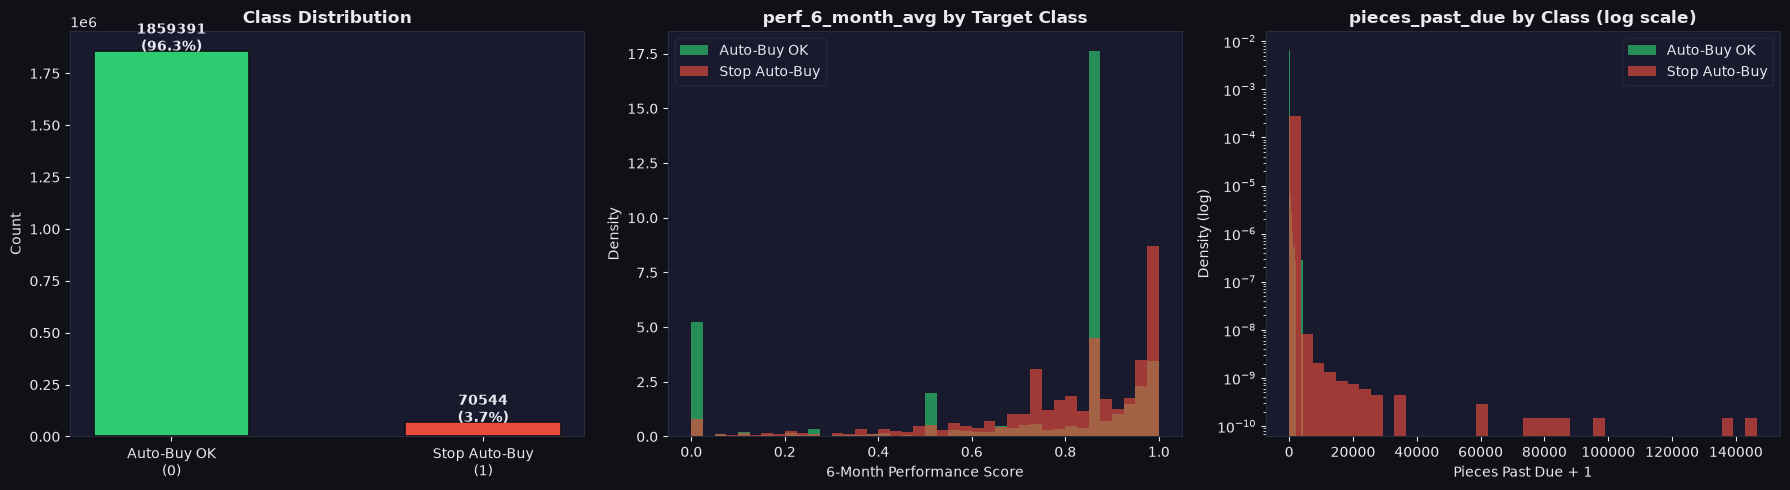

Imbalance ratio (N_neg / N_pos): 0.04x
This value is used directly as scale_pos_weight in XGBoost.


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor=BG)

ax     = axes[0]
counts = df_raw["stop_auto_buy"].value_counts()
bars   = ax.bar(["Auto-Buy OK\n(0)", "Stop Auto-Buy\n(1)"],
                counts.values, color=[GREEN, VAL_C],
                width=0.5, edgecolor=BG, linewidth=1.2)
for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 30,
            f"{count}\n({count/len(df_raw):.1%})",
            ha="center", fontsize=10, color=WHITE, fontweight="bold")
ax.set_title("Class Distribution", fontweight="bold")
ax.set_ylabel("Count")

ax = axes[1]
for val, color, label in zip([0, 1], [GREEN, VAL_C],
                               ["Auto-Buy OK", "Stop Auto-Buy"]):
    subset = df_raw[df_raw["stop_auto_buy"] == val]["perf_6_month_avg"].dropna()
    ax.hist(subset, bins=40, alpha=0.65, color=color,
            label=label, density=True, edgecolor="none")
ax.set_title("perf_6_month_avg by Target Class", fontweight="bold")
ax.set_xlabel("6-Month Performance Score")
ax.set_ylabel("Density")
ax.legend()

ax = axes[2]
for val, color, label in zip([0, 1], [GREEN, VAL_C],
                               ["Auto-Buy OK", "Stop Auto-Buy"]):
    subset = df_raw[df_raw["stop_auto_buy"] == val]["pieces_past_due"].dropna()
    ax.hist(subset + 1, bins=40, alpha=0.65, color=color,
            label=label, density=True, edgecolor="none", log=True)
ax.set_title("pieces_past_due by Class (log scale)", fontweight="bold")
ax.set_xlabel("Pieces Past Due + 1")
ax.set_ylabel("Density (log)")
ax.legend()

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/eda_overview.png", dpi=150,
            bbox_inches="tight", facecolor=BG)
plt.show()

imbalance_ratio = counts[0] / counts[1]
print(f"Imbalance ratio (N_neg / N_pos): {imbalance_ratio:.2f}x")
print(f"This value is used directly as scale_pos_weight in XGBoost.")


## 4. Feature Engineering

Domain-informed features constructed from raw schema.  
All division operations use ε = 1e-6 to prevent zero-division.

| Feature | Formula | Signal |
|---|---|---|
| `perf_trend` | perf_6 − perf_12 | Trajectory (negative = declining) |
| `perf_decay_rate` | perf_trend / (perf_12 + ε) | Relative degradation |
| `delivery_stress` | pieces_past_due / (national_inv + ε) | Overdue load vs. buffer |
| `backlog_transit_ratio` | local_bo_qty / (in_transit_qty + ε) | Unresolved backlog vs. pipeline |
| `forecast_accuracy_3m` | sales_3m / (forecast_3m + ε) | Demand planning quality |
| `inventory_coverage_days` | national_inv / (forecast_3m / 90 + ε) | Days of runway |
| `transit_exposure_ratio` | in_transit_qty / (national_inv + ε) | Unconfirmed stock dependency |
| `risk_flag_count` | Σ(5 binary flags) | Aggregate systemic risk |
| `compound_risk_index` | (1 − perf_6) × (risk_flag_count + 1) | Multiplicative risk signal |


In [6]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    EPS = 1e-6
    df  = df.copy()

    df["perf_trend"]              = df["perf_6_month_avg"] - df["perf_12_month_avg"]
    df["perf_decay_rate"]         = df["perf_trend"] / (df["perf_12_month_avg"] + EPS)
    df["delivery_stress"]         = df["pieces_past_due"] / (df["national_inv"] + EPS)
    df["backlog_transit_ratio"]   = df["local_bo_qty"] / (df["in_transit_qty"] + EPS)
    df["forecast_deviation_3m"]   = df["forecast_3_month"] - df["sales_3_month"]
    df["forecast_deviation_6m"]   = df["forecast_6_month"] - df["sales_6_month"]
    df["forecast_accuracy_3m"]    = df["sales_3_month"] / (df["forecast_3_month"] + EPS)
    daily_demand                  = df["forecast_3_month"] / 90.0
    df["inventory_coverage_days"] = df["national_inv"] / (daily_demand + EPS)
    df["transit_exposure_ratio"]  = df["in_transit_qty"] / (df["national_inv"] + EPS)
    risk_flags                    = ["potential_issue", "deck_risk", "oe_constraint",
                                     "ppap_risk", "rev_stop"]
    df["risk_flag_count"]         = df[risk_flags].sum(axis=1)
    df["compound_risk_index"]     = (1 - df["perf_6_month_avg"]) * (df["risk_flag_count"] + 1)

    return df


df_eng = engineer_features(df_raw)

DROP_COLS    = ["sku", "stop_auto_buy"]
FEATURE_COLS = [c for c in df_eng.columns if c not in DROP_COLS]


RAW_FEATURE_COLS = [c for c in df_raw.columns if c not in DROP_COLS]

X = df_eng[FEATURE_COLS]
y = df_eng["stop_auto_buy"]

print(f"Feature matrix  : {X.shape[0]} rows × {X.shape[1]} features")
print(f"  Raw features  : {len(RAW_FEATURE_COLS)}")
print(f"  Engineered    : {len(FEATURE_COLS) - len(RAW_FEATURE_COLS)} additional")
print(f"Target          : {y.sum()} positives / {len(y)} total ({y.mean():.2%})")


Feature matrix  : 1929935 rows × 36 features
  Raw features  : 25
  Engineered    : 11 additional
Target          : 1859391 positives / 1929935 total (96.34%)


## 5. Three-Way Split & Preprocessing

Three disjoint sets are used to prevent circular evaluation:

```
Train  (70%)  →  XGBoost training + early stopping
Val    (15%)  →  Threshold optimization (never seen during tree construction)
Test   (15%)  →  Final metric reporting (held out until Section 9)
```

The test set is touched exactly once: at final evaluation.


In [7]:
def build_preprocessor() -> Pipeline:
    """Median imputation + RobustScaler. Fit on train only."""
    return Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  RobustScaler()),
    ])


X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.1765, stratify=y_trainval, random_state=42
)

# --- Majority-class undersampling (train split only) ---
# Val and test keep the real 96%/4% distribution, so evaluation still reflects
# production reality. Only the rows the model actually trains on are rebalanced.
# No synthetic rows are created — every kept row is a real sample, just a
# random subset of the majority class ("Stop Auto-Buy"). Ratio of 3:1 preserves
# meaningful majority-class signal (missing a bad vendor is the costlier error)
# while cutting the 26:1 imbalance down to something scale_pos_weight can
# realistically fine-tune around.
UNDERSAMPLE_RATIO = 3.0
rng = np.random.RandomState(42)

minority_idx = y_train[y_train == 0].index   # "Auto-Buy OK" (minority)
majority_idx = y_train[y_train == 1].index   # "Stop Auto-Buy" (majority)
n_keep_majority   = min(len(majority_idx), int(len(minority_idx) * UNDERSAMPLE_RATIO))
keep_majority_idx = rng.choice(majority_idx, size=n_keep_majority, replace=False)
keep_idx = np.concatenate([minority_idx.values, keep_majority_idx])
rng.shuffle(keep_idx)

X_train_full, y_train_full = X_train, y_train   # kept for reference, not used downstream
X_train = X_train.loc[keep_idx]
y_train = y_train.loc[keep_idx]

preprocessor = build_preprocessor()
X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc   = preprocessor.transform(X_val)
X_test_proc  = preprocessor.transform(X_test)

N_neg            = (y_train == 0).sum()
N_pos            = (y_train == 1).sum()
SCALE_POS_WEIGHT = N_neg / N_pos

print(f"Split summary:")
print(f"  Train (undersampled) : {len(X_train):>7} samples  | Positive: {y_train.mean():.2%}  "
      f"(from {len(X_train_full)} original, kept ratio 1:{UNDERSAMPLE_RATIO:.0f})")
print(f"  Val                  : {len(X_val):>7} samples  | Positive: {y_val.mean():.2%}")
print(f"  Test                 : {len(X_test):>7} samples  | Positive: {y_test.mean():.2%}")
print(f"\nscale_pos_weight : {SCALE_POS_WEIGHT:.4f}  (N_neg={N_neg}, N_pos={N_pos})")
print("No synthetic data generated -- undersampling only drops real majority-class rows from training.")


Split summary:
  Train (undersampled) :  197516 samples  | Positive: 75.00%  (from 1350905 original, kept ratio 1:3)
  Val                  :  289539 samples  | Positive: 96.34%
  Test                 :  289491 samples  | Positive: 96.34%

scale_pos_weight : 0.3333  (N_neg=49379, N_pos=148137)
No synthetic data generated -- undersampling only drops real majority-class rows from training.


## 5b. scale_pos_weight Grid Search (Val Set)

The heuristic `scale_pos_weight = N_neg / N_pos` is a reasonable default, but it targets
overall log-loss, not minority-class ("Auto-Buy OK") detection specifically. This search
retrains lightweight candidate models across a grid of `scale_pos_weight` values around the
heuristic and keeps whichever value maximizes **minority-class F1** on the val set. The
selected value replaces `SCALE_POS_WEIGHT` and is what the full model in Section 6 trains with.


Grid-searching scale_pos_weight (minority-class F1 on val set)

multiplier | scale_pos_weight | best thresh | minority F1 |  macro F1
----------------------------------------------------------------------
      0.25 |          0.08333 |       0.050 |      0.7957 |    0.8938
      0.50 |          0.16667 |       0.091 |      0.8085 |    0.9005
      0.75 |          0.25000 |       0.109 |      0.8149 |    0.9039
      1.00 |          0.33333 |       0.122 |      0.8184 |    0.9058
      1.50 |          0.50000 |       0.195 |      0.8269 |    0.9101
      2.00 |          0.66667 |       0.199 |      0.8297 |    0.9116
      3.00 |          1.00000 |       0.208 |      0.8347 |    0.9143
      4.00 |          1.33333 |       0.263 |      0.8384 |    0.9161
      6.00 |          2.00000 |       0.303 |      0.8403 |    0.9171
      8.00 |          2.66667 |       0.389 |      0.8438 |    0.9189


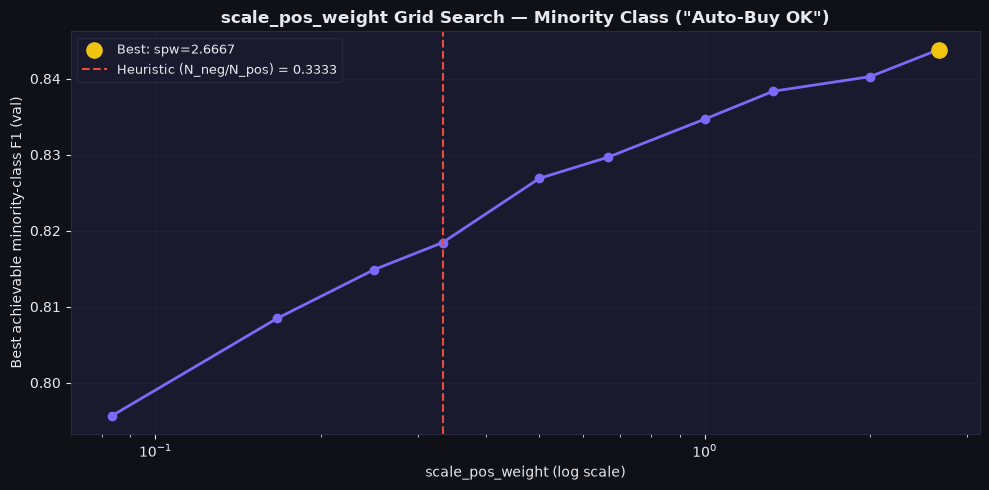


Heuristic scale_pos_weight : 0.33333
Tuned scale_pos_weight     : 2.66667  (used for final model below)
Minority F1 @ tuned spw    : 0.8438  (val, at trial threshold 0.389)


In [8]:
SCALE_POS_WEIGHT_HEURISTIC = SCALE_POS_WEIGHT
weight_grid = [0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0, 4.0, 6.0, 8.0]
candidates  = [round(SCALE_POS_WEIGHT_HEURISTIC * m, 5) for m in weight_grid]

grid_thresholds = np.linspace(0.05, 0.95, 200)
grid_results = []

print("Grid-searching scale_pos_weight (minority-class F1 on val set)\n")
print(f"{'multiplier':>10} | {'scale_pos_weight':>16} | {'best thresh':>11} | {'minority F1':>11} | {'macro F1':>9}")
print("-" * 70)

for m, spw in zip(weight_grid, candidates):
    trial_model = XGBClassifier(
        n_estimators          = 250,
        max_depth             = 10,
        min_child_weight      = 1,
        learning_rate         = 0.05,
        subsample             = 0.80,
        colsample_bytree      = 0.80,
        gamma                 = 0.05,
        reg_alpha             = 0.02,
        reg_lambda            = 0.50,
        scale_pos_weight      = spw,
        device                = XGB_DEVICE,
        eval_metric           = "logloss",
        early_stopping_rounds = 25,
        tree_method            = TREE_METHOD,
        n_jobs                = -1,
        random_state           = 42,
    )
    trial_model.fit(
        X_train_proc, y_train,
        eval_set=[(X_val_proc, y_val)],
        verbose=False,
    )
    trial_probs = trial_model.predict_proba(X_val_proc)[:, 1]

    best_f1_min, best_t, best_f1_macro = -1.0, 0.5, -1.0
    for t in grid_thresholds:
        preds    = (trial_probs >= t).astype(int)
        f1_min   = fbeta_score(y_val, preds, beta=1, pos_label=0, zero_division=0)
        f1_maj   = fbeta_score(y_val, preds, beta=1, pos_label=1, zero_division=0)
        f1_macro = (f1_min + f1_maj) / 2
        if f1_min > best_f1_min:
            best_f1_min, best_t, best_f1_macro = f1_min, t, f1_macro

    grid_results.append({
        "multiplier": m, "scale_pos_weight": spw,
        "best_thresh": best_t, "minority_f1": best_f1_min, "macro_f1": best_f1_macro,
    })
    print(f"{m:>10.2f} | {spw:>16.5f} | {best_t:>11.3f} | {best_f1_min:>11.4f} | {best_f1_macro:>9.4f}")

best_result = max(grid_results, key=lambda r: r["minority_f1"])
SCALE_POS_WEIGHT = best_result["scale_pos_weight"]

fig, ax = plt.subplots(figsize=(10, 5), facecolor=BG)
xs = [r["scale_pos_weight"] for r in grid_results]
ys = [r["minority_f1"] for r in grid_results]
ax.plot(xs, ys, marker="o", color=TRAIN_C, linewidth=2)
ax.scatter([best_result["scale_pos_weight"]], [best_result["minority_f1"]],
           color=BEST_C, s=120, zorder=5, label=f"Best: spw={best_result['scale_pos_weight']:.4f}")
ax.axvline(SCALE_POS_WEIGHT_HEURISTIC, color=VAL_C, linestyle="--", linewidth=1.5,
           label=f"Heuristic (N_neg/N_pos) = {SCALE_POS_WEIGHT_HEURISTIC:.4f}")
ax.set_xscale("log")
ax.set_xlabel("scale_pos_weight (log scale)")
ax.set_ylabel("Best achievable minority-class F1 (val)")
ax.set_title("scale_pos_weight Grid Search \u2014 Minority Class (\"Auto-Buy OK\")", fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.6)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/scale_pos_weight_grid_search.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()

print(f"\nHeuristic scale_pos_weight : {SCALE_POS_WEIGHT_HEURISTIC:.5f}")
print(f"Tuned scale_pos_weight     : {SCALE_POS_WEIGHT:.5f}  (used for final model below)")
print(f"Minority F1 @ tuned spw    : {best_result['minority_f1']:.4f}  (val, at trial threshold {best_result['best_thresh']:.3f})")


## 6. XGBoost Training with Metric Monitoring

`evals_result` captures per-round `logloss` and `error` for both train and val sets.  
Early stopping (patience = 40 rounds) uses val logloss as the criterion.  
The val set here is used **only for early stopping** — threshold optimization happens separately in Section 8.


In [9]:
model = XGBClassifier(
    n_estimators          = 700,
    max_depth             = 10,
    min_child_weight      = 1,
    learning_rate         = 0.03,
    subsample             = 0.80,
    colsample_bytree      = 0.80,
    gamma                 = 0.05,
    reg_alpha             = 0.02,
    reg_lambda            = 0.50,
    scale_pos_weight      = SCALE_POS_WEIGHT,
    device                = XGB_DEVICE,
    eval_metric           = ["error", "logloss"],
    early_stopping_rounds = 40,
    tree_method           = TREE_METHOD,
    n_jobs                = -1,
    random_state          = 42,
)

print("Training XGBoost Supplier Auditor (verbose every 50 rounds)\n")

model.fit(
    X_train_proc, y_train,
    eval_set=[
        (X_train_proc, y_train),
        (X_val_proc,   y_val),
    ],
    verbose=50,
)

raw_history = model.evals_result()

TRAIN_LOSS = raw_history["validation_0"]["logloss"]
VAL_LOSS   = raw_history["validation_1"]["logloss"]
TRAIN_ACC  = [1.0 - e for e in raw_history["validation_0"]["error"]]
VAL_ACC    = [1.0 - e for e in raw_history["validation_1"]["error"]]
BEST_ROUND = model.best_iteration
N_ROUNDS   = len(TRAIN_LOSS)
ROUNDS     = list(range(1, N_ROUNDS + 1))

print(f"\nBest round      : {BEST_ROUND + 1}")
print(f"Val loss @ best : {VAL_LOSS[BEST_ROUND]:.6f}")
print(f"Val acc  @ best : {VAL_ACC[BEST_ROUND]:.4f}")


Training XGBoost Supplier Auditor (verbose every 50 rounds)

[0]	validation_0-error:0.25000	validation_0-logloss:0.55416	validation_1-error:0.03655	validation_1-logloss:0.24040
[50]	validation_0-error:0.06315	validation_0-logloss:0.21590	validation_1-error:0.01490	validation_1-logloss:0.09296
[100]	validation_0-error:0.04916	validation_0-logloss:0.15361	validation_1-error:0.01498	validation_1-logloss:0.06255
[150]	validation_0-error:0.04316	validation_0-logloss:0.12745	validation_1-error:0.01443	validation_1-logloss:0.05320
[200]	validation_0-error:0.03904	validation_0-logloss:0.11246	validation_1-error:0.01394	validation_1-logloss:0.04941
[250]	validation_0-error:0.03607	validation_0-logloss:0.10278	validation_1-error:0.01348	validation_1-logloss:0.04729
[300]	validation_0-error:0.03314	validation_0-logloss:0.09424	validation_1-error:0.01312	validation_1-logloss:0.04553
[350]	validation_0-error:0.03053	validation_0-logloss:0.08693	validation_1-error:0.01276	validation_1-logloss:0.0441

## 7. Training Monitor — Learning Curves

Four panels:
1. **Train Loss vs Val Loss** — convergence quality
2. **Train Accuracy vs Val Accuracy** — generalization tracking
3. **Loss Gap (Val − Train)** — overfitting indicator
4. **Accuracy Gap (Train − Val)** — generalization indicator


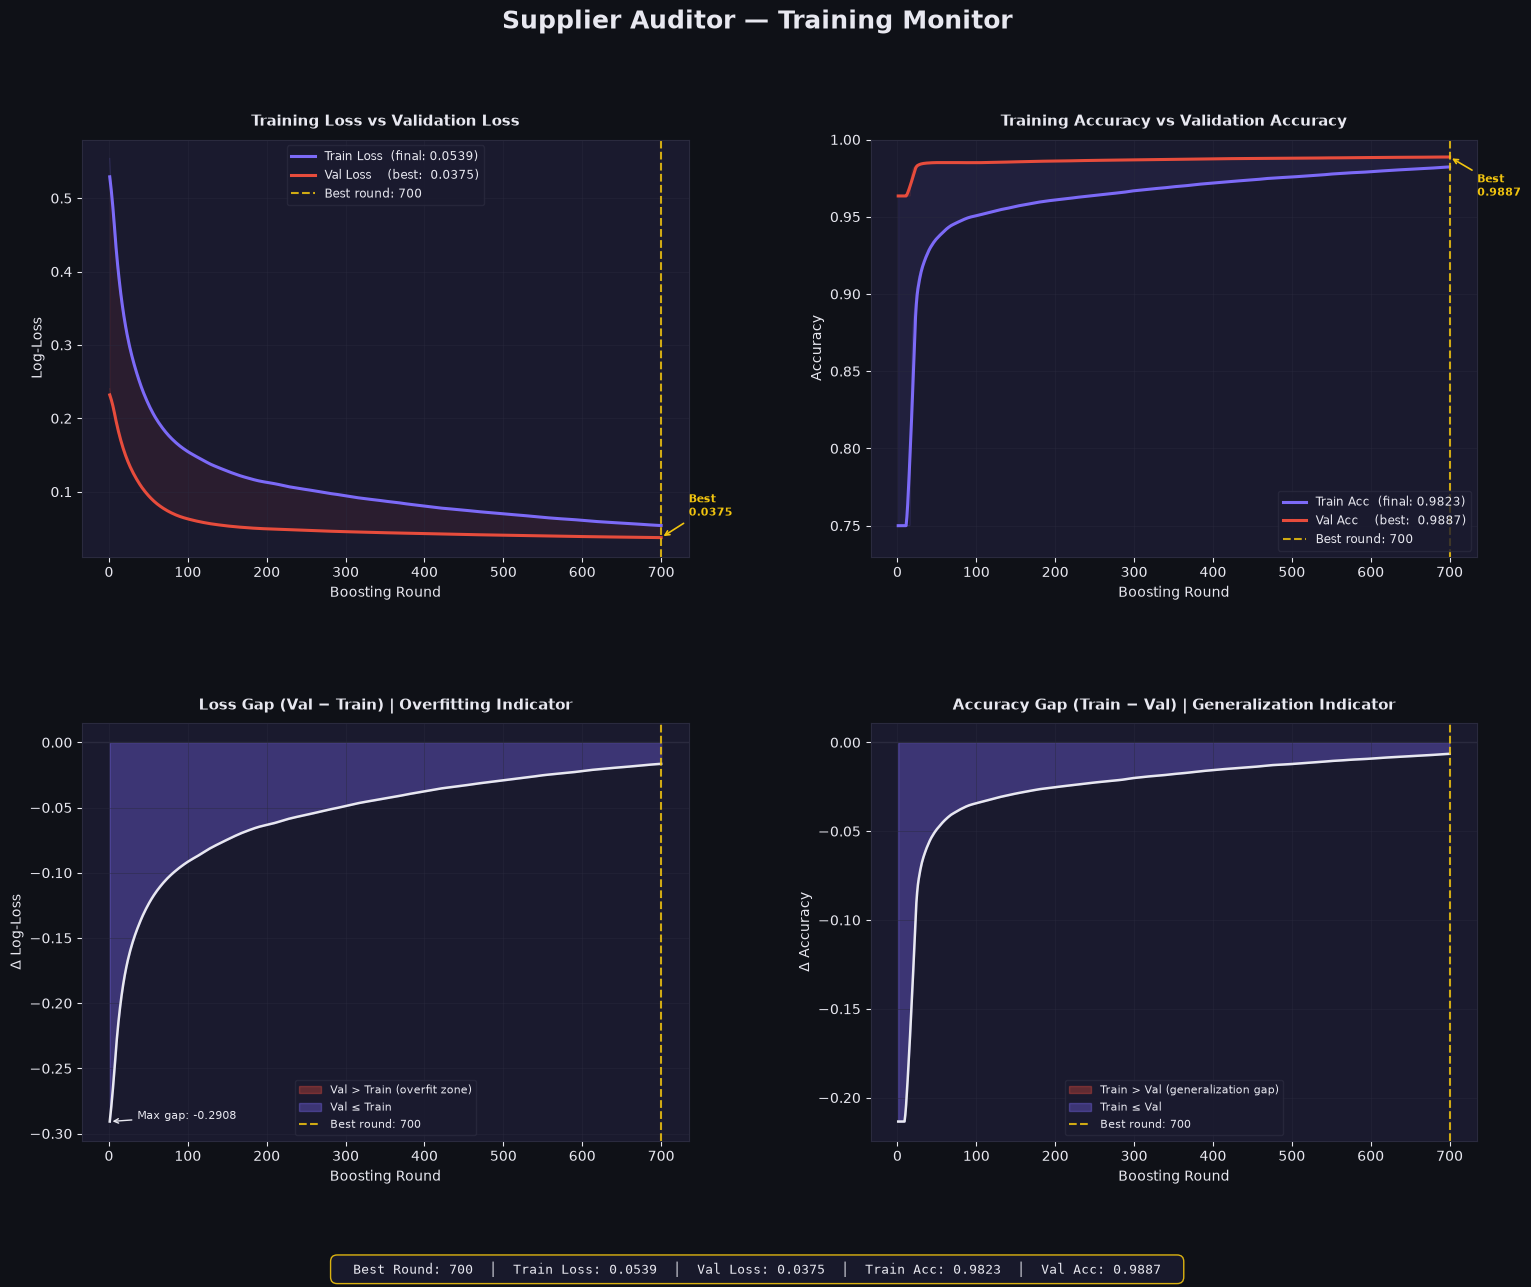

Saved → outputs/training_monitor.png


In [10]:
def smooth(values, window: int = 12):
    kernel = np.ones(window) / window
    padded = np.pad(values, (window // 2, window // 2), mode="edge")
    return np.convolve(padded, kernel, mode="valid")[:len(values)]


train_loss_s = smooth(TRAIN_LOSS)
val_loss_s   = smooth(VAL_LOSS)
train_acc_s  = smooth(TRAIN_ACC)
val_acc_s    = smooth(VAL_ACC)
best_display = BEST_ROUND + 1


def annotate_best(ax, x, y_v, offset_x_frac=0.05, offset_y=0.02):
    ax.annotate(
        f"Best\n{y_v:.4f}",
        xy=(x, y_v),
        xytext=(x + len(ROUNDS) * offset_x_frac, y_v + offset_y),
        color=BEST_C, fontsize=8, fontweight="bold",
        arrowprops=dict(arrowstyle="->", color=BEST_C, lw=1.2),
    )


def style_ax(ax, title, xlabel, ylabel):
    ax.set_title(title, color=WHITE, fontsize=11, fontweight="bold", pad=10)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.6)
    ax.axvline(best_display, color=BEST_C, linestyle="--", linewidth=1.5,
               alpha=0.85, label=f"Best round: {best_display}")


fig = plt.figure(figsize=(18, 13), facecolor=BG)
fig.suptitle("Supplier Auditor — Training Monitor",
             fontsize=18, fontweight="bold", color=WHITE, y=0.98)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.40, wspace=0.30)

ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(ROUNDS, TRAIN_LOSS, color=TRAIN_C, alpha=0.18, linewidth=0.8)
ax1.plot(ROUNDS, VAL_LOSS,   color=VAL_C,   alpha=0.18, linewidth=0.8)
ax1.plot(ROUNDS, train_loss_s, color=TRAIN_C, linewidth=2.2,
         label=f"Train Loss  (final: {TRAIN_LOSS[-1]:.4f})")
ax1.plot(ROUNDS, val_loss_s,   color=VAL_C,   linewidth=2.2,
         label=f"Val Loss    (best:  {VAL_LOSS[BEST_ROUND]:.4f})")
ax1.fill_between(ROUNDS, train_loss_s, val_loss_s, alpha=0.08, color=VAL_C)
annotate_best(ax1, best_display, VAL_LOSS[BEST_ROUND], offset_y=0.03)
style_ax(ax1, "Training Loss vs Validation Loss", "Boosting Round", "Log-Loss")
ax1.legend(fontsize=8.5)

ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(ROUNDS, TRAIN_ACC, color=TRAIN_C, alpha=0.18, linewidth=0.8)
ax2.plot(ROUNDS, VAL_ACC,   color=VAL_C,   alpha=0.18, linewidth=0.8)
ax2.plot(ROUNDS, train_acc_s, color=TRAIN_C, linewidth=2.2,
         label=f"Train Acc  (final: {TRAIN_ACC[-1]:.4f})")
ax2.plot(ROUNDS, val_acc_s,   color=VAL_C,   linewidth=2.2,
         label=f"Val Acc    (best:  {VAL_ACC[BEST_ROUND]:.4f})")
ax2.fill_between(ROUNDS, train_acc_s, val_acc_s, alpha=0.08, color=TRAIN_C)
annotate_best(ax2, best_display, VAL_ACC[BEST_ROUND], offset_y=-0.025)
ax2.set_ylim(max(0.0, min(TRAIN_ACC+VAL_ACC)-0.02),
             min(1.0, max(TRAIN_ACC+VAL_ACC)+0.02))
style_ax(ax2, "Training Accuracy vs Validation Accuracy",
         "Boosting Round", "Accuracy")
ax2.legend(fontsize=8.5, loc="lower right")

ax3 = fig.add_subplot(gs[1, 0])
loss_gap = smooth([v-t for v,t in zip(VAL_LOSS,TRAIN_LOSS)], window=15)
pos_mask = np.array(loss_gap) > 0
ax3.fill_between(ROUNDS, 0, loss_gap, where=pos_mask,
                 color=VAL_C, alpha=0.35, label="Val > Train (overfit zone)")
ax3.fill_between(ROUNDS, 0, loss_gap, where=~pos_mask,
                 color=TRAIN_C, alpha=0.35, label="Val ≤ Train")
ax3.plot(ROUNDS, loss_gap, color=WHITE, linewidth=1.8)
ax3.axhline(0, color=GRID, linewidth=1.0)
max_idx = int(np.argmax(np.abs(loss_gap)))
ax3.annotate(f"Max gap: {loss_gap[max_idx]:.4f}",
             xy=(ROUNDS[max_idx], loss_gap[max_idx]),
             xytext=(ROUNDS[max_idx]+len(ROUNDS)*0.05, loss_gap[max_idx]+0.002),
             color=WHITE, fontsize=8,
             arrowprops=dict(arrowstyle="->", color=WHITE, lw=1.0))
style_ax(ax3, "Loss Gap (Val − Train) | Overfitting Indicator",
         "Boosting Round", "Δ Log-Loss")
ax3.legend(fontsize=8)

ax4 = fig.add_subplot(gs[1, 1])
acc_gap   = smooth([t-v for t,v in zip(TRAIN_ACC,VAL_ACC)], window=15)
pos_mask2 = np.array(acc_gap) > 0
ax4.fill_between(ROUNDS, 0, acc_gap, where=pos_mask2,
                 color=VAL_C, alpha=0.35, label="Train > Val (generalization gap)")
ax4.fill_between(ROUNDS, 0, acc_gap, where=~pos_mask2,
                 color=TRAIN_C, alpha=0.35, label="Train ≤ Val")
ax4.plot(ROUNDS, acc_gap, color=WHITE, linewidth=1.8)
ax4.axhline(0, color=GRID, linewidth=1.0)
style_ax(ax4, "Accuracy Gap (Train − Val) | Generalization Indicator",
         "Boosting Round", "Δ Accuracy")
ax4.legend(fontsize=8)

fig.text(0.5, 0.005,
    f"  Best Round: {best_display}  │  "
    f"Train Loss: {TRAIN_LOSS[BEST_ROUND]:.4f}  │  "
    f"Val Loss: {VAL_LOSS[BEST_ROUND]:.4f}  │  "
    f"Train Acc: {TRAIN_ACC[BEST_ROUND]:.4f}  │  "
    f"Val Acc: {VAL_ACC[BEST_ROUND]:.4f}  ",
    ha="center", va="bottom", fontsize=9.5, color=WHITE,
    fontfamily="monospace",
    bbox=dict(boxstyle="round,pad=0.5", facecolor=PANEL,
              edgecolor=BEST_C, alpha=0.9))

plt.savefig(f"{OUTPUT_DIR}/training_monitor.png", dpi=150,
            bbox_inches="tight", facecolor=BG)
plt.show()
print(f"Saved → {OUTPUT_DIR}/training_monitor.png")


## 8. Decision Threshold Optimization (Val Set)

The threshold is optimized exclusively on the **val set**, which was never used during tree construction.
The test set remains untouched until Section 9.

Selection targets **macro-F1** (mean of per-class F1) rather than MCC alone. With a 96%/4% class split,
F2 and accuracy are dominated by the majority class ("Stop Auto-Buy") almost regardless of threshold;
macro-F1 explicitly rewards improving minority-class ("Auto-Buy OK") recall/precision, which is where the
imbalance actually hurts. F2, MCC, and the minority-class F1 curve are still plotted for reference.


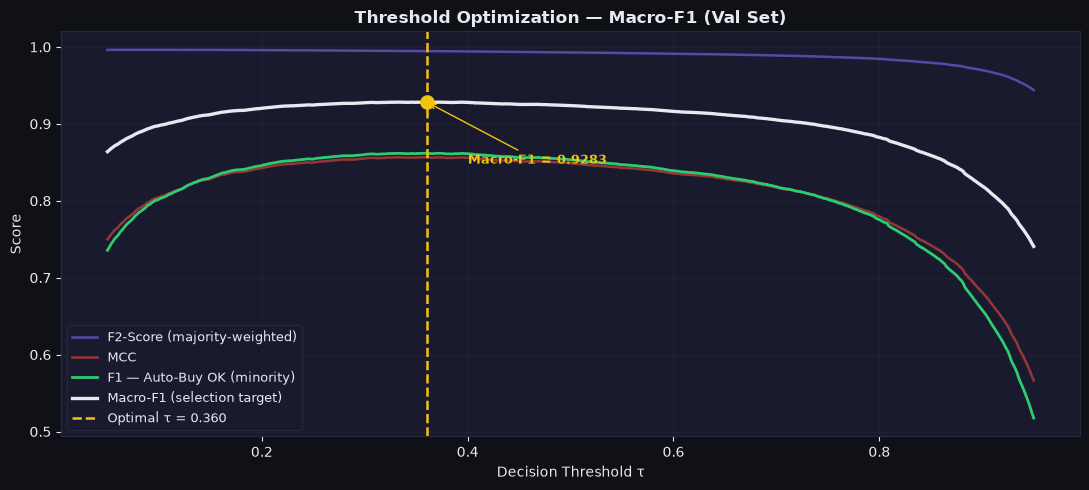

Optimal threshold (macro-F1)         : 0.3602  (val set, applied to test set)
F1 (Auto-Buy OK, minority) @ optimal : 0.8619
Macro-F1 @ optimal                   : 0.9283
F2  @ optimal (val)                  : 0.9946
MCC @ optimal (val)                  : 0.8566


In [11]:
val_probs  = model.predict_proba(X_val_proc)[:, 1]
thresholds = np.linspace(0.05, 0.95, 500)
f2_scores   = []
mcc_scores  = []
f1_minority = []
f1_macro    = []

for t in thresholds:
    preds = (val_probs >= t).astype(int)
    f2_scores.append(fbeta_score(y_val, preds, beta=2, zero_division=0))
    mcc_scores.append(matthews_corrcoef(y_val, preds))
    f1_min = fbeta_score(y_val, preds, beta=1, pos_label=0, zero_division=0)
    f1_maj = fbeta_score(y_val, preds, beta=1, pos_label=1, zero_division=0)
    f1_minority.append(f1_min)
    f1_macro.append((f1_min + f1_maj) / 2)

best_idx   = int(np.argmax(f1_macro))
OPT_THRESH = float(thresholds[best_idx])

fig, ax = plt.subplots(figsize=(11, 5), facecolor=BG)
ax.plot(thresholds, f2_scores,   color=TRAIN_C, linewidth=1.8, alpha=0.6, label="F2-Score (majority-weighted)")
ax.plot(thresholds, mcc_scores,  color=VAL_C,   linewidth=1.8, alpha=0.6, label="MCC")
ax.plot(thresholds, f1_minority, color=GREEN,   linewidth=2.0, label="F1 \u2014 Auto-Buy OK (minority)")
ax.plot(thresholds, f1_macro,    color=WHITE,   linewidth=2.4, label="Macro-F1 (selection target)")
ax.axvline(OPT_THRESH, color=BEST_C, linestyle="--", linewidth=1.8,
           label=f"Optimal \u03c4 = {OPT_THRESH:.3f}")
ax.scatter([OPT_THRESH], [f1_macro[best_idx]], color=BEST_C, s=90, zorder=5)
ax.annotate(f"Macro-F1 = {f1_macro[best_idx]:.4f}",
            xy=(OPT_THRESH, f1_macro[best_idx]),
            xytext=(OPT_THRESH+0.04, f1_macro[best_idx]-0.08),
            color=BEST_C, fontsize=9, fontweight="bold",
            arrowprops=dict(arrowstyle="->", color=BEST_C))
ax.set_title("Threshold Optimization \u2014 Macro-F1 (Val Set)", fontweight="bold")
ax.set_xlabel("Decision Threshold \u03c4")
ax.set_ylabel("Score")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.6)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/threshold_optimization.png", dpi=150,
            bbox_inches="tight", facecolor=BG)
plt.show()

print(f"Optimal threshold (macro-F1)         : {OPT_THRESH:.4f}  (val set, applied to test set)")
print(f"F1 (Auto-Buy OK, minority) @ optimal : {f1_minority[best_idx]:.4f}")
print(f"Macro-F1 @ optimal                   : {f1_macro[best_idx]:.4f}")
print(f"F2  @ optimal (val)                  : {f2_scores[best_idx]:.4f}")
print(f"MCC @ optimal (val)                  : {mcc_scores[best_idx]:.4f}")


## 9. Final Evaluation — Held-Out Test Set

**This is the first and only time the test set is used.**  
All metrics reported here are uncontaminated — the threshold came from the val set, 
the model from the train set. These are the values for the paper's results table.

**Metric rationale:**
- **F2-Score** — primary; penalizes missed bad vendors (β=2 weights recall 2×)
- **MCC** — balanced, imbalance-invariant (Chicco & Jurman, 2020)
- **ROC-AUC** — threshold-free discrimination ability
- **PR-AUC** — preferred over ROC-AUC under class imbalance (Davis & Goadrich, 2006)


In [12]:
test_probs = model.predict_proba(X_test_proc)[:, 1]
test_preds = (test_probs >= OPT_THRESH).astype(int)

f2         = fbeta_score(y_test, test_preds, beta=2, zero_division=0)
mcc        = matthews_corrcoef(y_test, test_preds)
roc_auc    = roc_auc_score(y_test, test_probs)
pr_auc     = average_precision_score(y_test, test_probs)
acc        = accuracy_score(y_test, test_preds)
logloss    = log_loss(y_test, test_probs)

XGB_METRICS = {
    "Accuracy": acc, "Log-Loss": logloss,
    "F2-Score (β=2)": f2, "MCC": mcc,
    "ROC-AUC": roc_auc, "PR-AUC": pr_auc
}

results_df = pd.DataFrame({
    "Metric" : list(XGB_METRICS.keys()),
    "Value"  : [round(v, 4) for v in XGB_METRICS.values()],
    "Notes"  : [
        "Overall correct predictions",
        "Calibration quality",
        "PRIMARY — recall-weighted (β=2)",
        "Balanced — imbalance-invariant",
        "Discrimination ability (threshold-free)",
        "Preferred under class imbalance",
    ]
})
print(results_df.to_string(index=False))

print("\nClassification Report (at optimal threshold):")
print(classification_report(y_test, test_preds,
                            target_names=["Auto-Buy OK", "Stop Auto-Buy"]))


        Metric  Value                                   Notes
      Accuracy 0.9895             Overall correct predictions
      Log-Loss 0.0383                     Calibration quality
F2-Score (β=2) 0.9944         PRIMARY — recall-weighted (β=2)
           MCC 0.8524          Balanced — imbalance-invariant
       ROC-AUC 0.9938 Discrimination ability (threshold-free)
        PR-AUC 0.9997         Preferred under class imbalance

Classification Report (at optimal threshold):
               precision    recall  f1-score   support

  Auto-Buy OK       0.85      0.86      0.86     10582
Stop Auto-Buy       0.99      0.99      0.99    278909

     accuracy                           0.99    289491
    macro avg       0.92      0.93      0.93    289491
 weighted avg       0.99      0.99      0.99    289491



## 10. 5-Fold Stratified Cross-Validation

A single train/test split produces point estimates with no variance information. Q1 journals require **mean +/- std** across folds to demonstrate results are not attributable to a lucky random split.

Each fold trains a fresh XGBoost model with the same hyperparameters. The globally tuned `OPT_THRESH` (MCC-optimized on the held-out val set in Section 8) is applied to every fold to keep evaluation consistent with the main test-set report and to avoid per-fold threshold overfitting on the small within-fold holdout.


 Fold |       F2 |      MCC |   ROC-AUC |   PR-AUC |  Accuracy
──────────────────────────────────────────────────────────────
    1  |   0.9944 |   0.8547 |    0.9944 |   0.9998 |    0.9897
    2  |   0.9944 |   0.8514 |    0.9938 |   0.9997 |    0.9895
    3  |   0.9940 |   0.8476 |    0.9944 |   0.9998 |    0.9891
    4  |   0.9945 |   0.8509 |    0.9940 |   0.9997 |    0.9895
    5  |   0.9942 |   0.8488 |    0.9943 |   0.9998 |    0.9892
──────────────────────────────────────────────────────────────
  Mean |   0.9943 |   0.8507 |    0.9942 |   0.9998 |    0.9894
  Std  |   0.0002 |   0.0024 |    0.0002 |   0.0000 |    0.0002


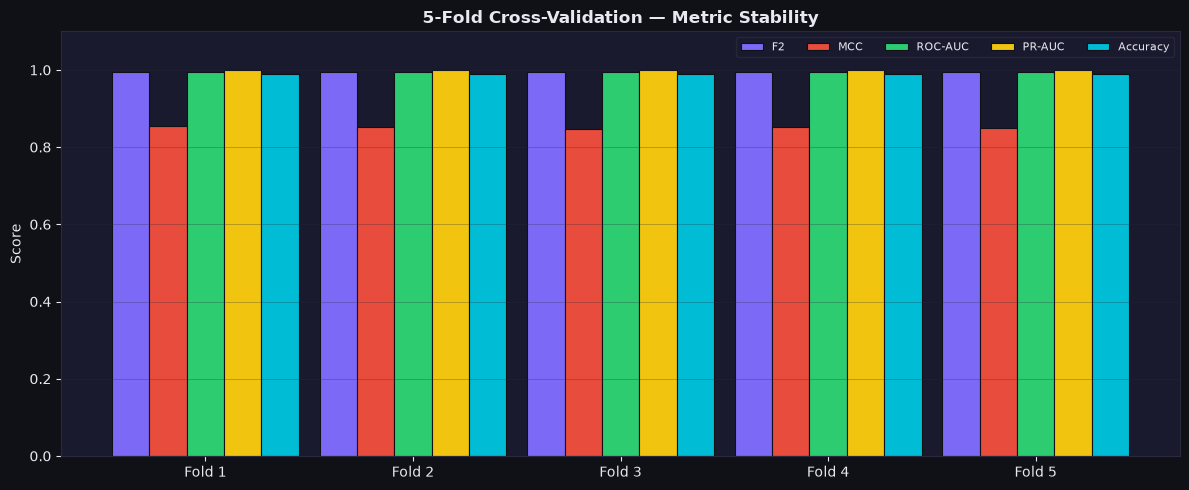


Paper-ready CV summary:
  F2             : 0.9943 ± 0.0002
  MCC            : 0.8507 ± 0.0024
  ROC-AUC        : 0.9942 ± 0.0002
  PR-AUC         : 0.9998 ± 0.0000
  Accuracy       : 0.9894 ± 0.0002


In [13]:
cv          = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_metrics  = {"F2": [], "MCC": [], "ROC-AUC": [], "PR-AUC": [], "Accuracy": []}

# Same scale_pos_weight multiplier the Section 5b grid search found, reapplied
# per fold on top of that fold's own undersampled heuristic. This avoids
# re-running the full grid search 5x while still validating the exact method
# used for the main model: undersample train -> weight -> fixed threshold.
SPW_MULTIPLIER = SCALE_POS_WEIGHT / SCALE_POS_WEIGHT_HEURISTIC

print(f"{'Fold':>5} | {'F2':>8} | {'MCC':>8} | {'ROC-AUC':>9} | {'PR-AUC':>8} | {'Accuracy':>9}")
print("─" * 62)

for fold, (tr_idx, te_idx) in enumerate(cv.split(X, y), 1):
    X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
    y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]

    X_tr_m, X_th, y_tr_m, y_th = train_test_split(
        X_tr, y_tr, test_size=0.15, stratify=y_tr, random_state=42
    )

    # Majority-class undersampling, mirroring the main split (Section 5).
    fold_rng           = np.random.RandomState(42)
    fold_minority_idx  = y_tr_m[y_tr_m == 0].index
    fold_majority_idx  = y_tr_m[y_tr_m == 1].index
    fold_n_keep        = min(len(fold_majority_idx), int(len(fold_minority_idx) * UNDERSAMPLE_RATIO))
    fold_keep_majority = fold_rng.choice(fold_majority_idx, size=fold_n_keep, replace=False)
    fold_keep_idx      = np.concatenate([fold_minority_idx.values, fold_keep_majority])
    fold_rng.shuffle(fold_keep_idx)
    X_tr_m = X_tr_m.loc[fold_keep_idx]
    y_tr_m = y_tr_m.loc[fold_keep_idx]

    pp = build_preprocessor()
    X_tr_p  = pp.fit_transform(X_tr_m)
    X_th_p  = pp.transform(X_th)
    X_te_p  = pp.transform(X_te)

    spw = (y_tr_m == 0).sum() / (y_tr_m == 1).sum() * SPW_MULTIPLIER

    m = XGBClassifier(
        n_estimators=700, max_depth=10, min_child_weight=1,
        learning_rate=0.03, subsample=0.80, colsample_bytree=0.80,
        gamma=0.05, reg_alpha=0.02, reg_lambda=0.50,
        scale_pos_weight=spw,
        eval_metric=["error","logloss"], tree_method=TREE_METHOD,
        n_jobs=-1, random_state=42, device=XGB_DEVICE
    )
    m.fit(X_tr_p, y_tr_m,
          eval_set=[(X_tr_p,y_tr_m),(X_th_p,y_th)], verbose=False)


    te_probs = m.predict_proba(X_te_p)[:, 1]
    te_preds = (te_probs >= OPT_THRESH).astype(int)

    fold_f2  = fbeta_score(y_te, te_preds, beta=2, zero_division=0)
    fold_mcc = matthews_corrcoef(y_te, te_preds)
    fold_roc = roc_auc_score(y_te, te_probs)
    fold_pr  = average_precision_score(y_te, te_probs)
    fold_acc = accuracy_score(y_te, te_preds)

    cv_metrics["F2"].append(fold_f2)
    cv_metrics["MCC"].append(fold_mcc)
    cv_metrics["ROC-AUC"].append(fold_roc)
    cv_metrics["PR-AUC"].append(fold_pr)
    cv_metrics["Accuracy"].append(fold_acc)

    print(f"  {fold:>3}  | {fold_f2:>8.4f} | {fold_mcc:>8.4f} | "
          f"{fold_roc:>9.4f} | {fold_pr:>8.4f} | {fold_acc:>9.4f}")

print("─" * 62)
print(f"  Mean | "
      f"{np.mean(cv_metrics['F2']):>8.4f} | "
      f"{np.mean(cv_metrics['MCC']):>8.4f} | "
      f"{np.mean(cv_metrics['ROC-AUC']):>9.4f} | "
      f"{np.mean(cv_metrics['PR-AUC']):>8.4f} | "
      f"{np.mean(cv_metrics['Accuracy']):>9.4f}")
print(f"  Std  | "
      f"{np.std(cv_metrics['F2']):>8.4f} | "
      f"{np.std(cv_metrics['MCC']):>8.4f} | "
      f"{np.std(cv_metrics['ROC-AUC']):>9.4f} | "
      f"{np.std(cv_metrics['PR-AUC']):>8.4f} | "
      f"{np.std(cv_metrics['Accuracy']):>9.4f}")

fig, ax = plt.subplots(figsize=(12, 5), facecolor=BG)
x     = np.arange(5)
width = 0.18
colors_cv = [TRAIN_C, VAL_C, GREEN, BEST_C, "#00bcd4"]
for i, (metric, vals) in enumerate(cv_metrics.items()):
    ax.bar(x + i*width, vals, width, label=metric,
           color=colors_cv[i], edgecolor=BG, linewidth=0.8)
ax.set_xticks(x + 2*width)
ax.set_xticklabels([f"Fold {i+1}" for i in range(5)])
ax.set_title("5-Fold Cross-Validation — Metric Stability", fontweight="bold")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.1)
ax.legend(fontsize=8, ncol=5)
ax.grid(True, alpha=0.4, axis="y")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/cv_stability.png", dpi=150,
            bbox_inches="tight", facecolor=BG)
plt.show()

print(f"\nPaper-ready CV summary:")
for metric, vals in cv_metrics.items():
    print(f"  {metric:<15}: {np.mean(vals):.4f} ± {np.std(vals):.4f}")


## 11. Baseline Model Comparison



| Baseline | Purpose |
|---|---|
| `DummyClassifier (majority)` | Proves model beats the trivial all-negative predictor |
| `LogisticRegression` | Standard linear baseline; tests whether non-linearity is needed |
| `RandomForest` | Tree ensemble baseline; isolates XGBoost-specific gains |

All baselines use the same preprocessor fit on the same training data.


Model Comparison on Test Set (each baseline threshold MCC-tuned on val set)
              Model  F2-Score    MCC  ROC-AUC  PR-AUC  Accuracy
Majority Classifier    0.9925 0.0000   0.5000  0.9634    0.9634
Logistic Regression    0.9676 0.1259   0.7587  0.9855    0.9379
      Random Forest    0.9953 0.8810   0.9962  0.9998    0.9915
 XGBoost (Proposed)    0.9944 0.8524   0.9938  0.9997    0.9895

Thresholds used:
  Majority Classifier            tau = 0.5
  Logistic Regression            tau = 0.457
  Random Forest                  tau = 0.1812
  XGBoost (Proposed)             tau = 0.3602


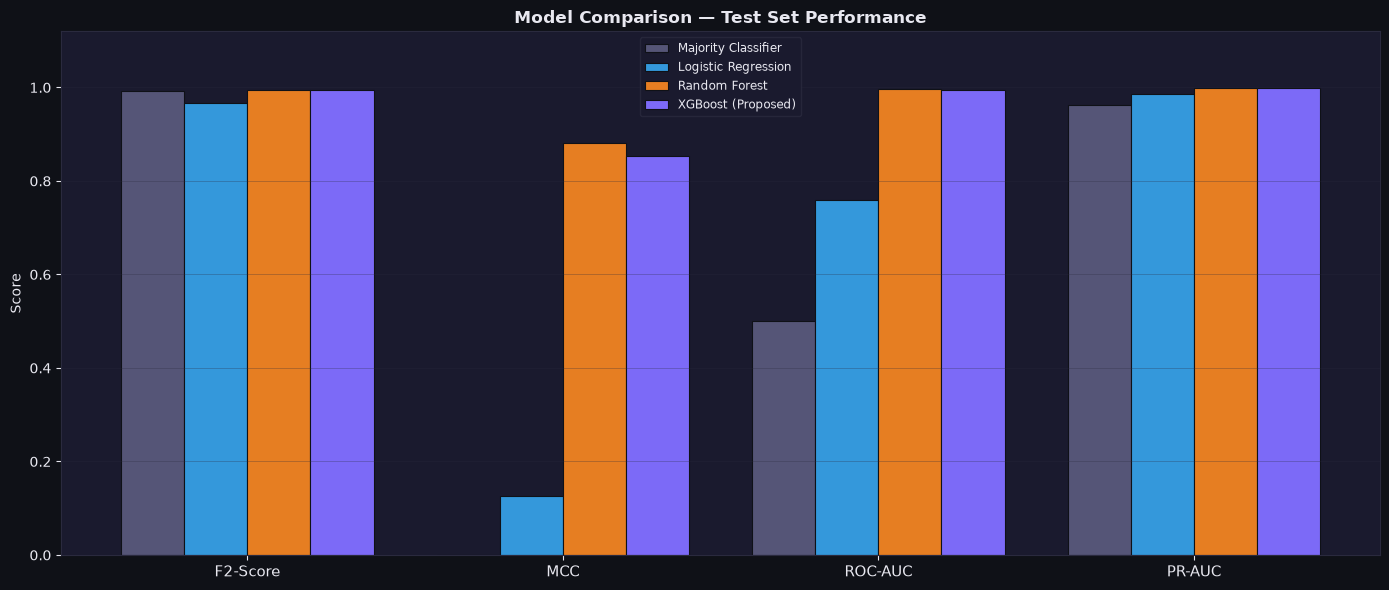

In [14]:
def evaluate_classifier(name, clf, X_tr, y_tr, X_te, y_te,
                        threshold=0.5, use_proba=True,
                        X_val=None, y_val=None):
    """Fits clf; tunes threshold on val set if provided, else uses given threshold."""
    clf.fit(X_tr, y_tr)

    if use_proba:
        probs = clf.predict_proba(X_te)[:, 1]
        if X_val is not None and y_val is not None:
            vp       = clf.predict_proba(X_val)[:, 1]
            thr_grid = np.linspace(0.05, 0.95, 200)

            def _macro_f1(t):
                p      = (vp >= t).astype(int)
                f1_min = fbeta_score(y_val, p, beta=1, pos_label=0, zero_division=0)
                f1_maj = fbeta_score(y_val, p, beta=1, pos_label=1, zero_division=0)
                return (f1_min + f1_maj) / 2

            # Macro-F1, not MCC -- matches the criterion used to pick OPT_THRESH
            # for XGBoost in Section 8, so every model in this comparison is
            # thresholded the same way.
            threshold = float(thr_grid[np.argmax([_macro_f1(t) for t in thr_grid])])
        preds = (probs >= threshold).astype(int)
        roc   = roc_auc_score(y_te, probs)
        pr    = average_precision_score(y_te, probs)
    else:
        preds = clf.predict(X_te)
        probs = preds.astype(float)
        roc   = 0.5
        pr    = y_te.mean()
        threshold = 0.5

    return {
        "Model"      : name,
        "F2-Score"   : round(fbeta_score(y_te, preds, beta=2, zero_division=0), 4),
        "MCC"        : round(matthews_corrcoef(y_te, preds), 4),
        "ROC-AUC"    : round(roc, 4),
        "PR-AUC"     : round(pr,  4),
        "Accuracy"   : round(accuracy_score(y_te, preds), 4),
        "_probs"     : probs,
        "_preds"     : preds,
        "_threshold" : round(threshold, 4),
    }


baselines = [
    evaluate_classifier(
        "Majority Classifier",
        DummyClassifier(strategy="most_frequent"),
        X_train_proc, y_train, X_test_proc, y_test,
        use_proba=False
    ),
    evaluate_classifier(
        "Logistic Regression",
        LogisticRegression(class_weight="balanced", max_iter=1000,
                           random_state=42),
        X_train_proc, y_train, X_test_proc, y_test,
        X_val=X_val_proc, y_val=y_val
    ),
    evaluate_classifier(
        "Random Forest",
        RandomForestClassifier(n_estimators=300, class_weight="balanced",
                               n_jobs=-1, random_state=42),
        X_train_proc, y_train, X_test_proc, y_test,
        X_val=X_val_proc, y_val=y_val
    ),
]

# Add XGBoost row
xgb_row = {
    "Model"      : "XGBoost (Proposed)",
    "F2-Score"   : round(f2,      4),
    "MCC"        : round(mcc,     4),
    "ROC-AUC"    : round(roc_auc, 4),
    "PR-AUC"     : round(pr_auc,  4),
    "Accuracy"   : round(acc,     4),
    "_probs"     : test_probs,
    "_preds"     : test_preds,
    "_threshold" : round(OPT_THRESH, 4),
}

all_models = baselines + [xgb_row]

compare_df = pd.DataFrame([{k: v for k, v in m.items() if not k.startswith("_")}
                            for m in all_models])
print("Model Comparison on Test Set (each baseline threshold MCC-tuned on val set)")
print("=" * 72)
print(compare_df.to_string(index=False))
print("=" * 72)
print("\nThresholds used:")
for m in all_models:
    print(f"  {m['Model']:<30} tau = {m.get('_threshold', 'N/A')}")

metrics_to_plot = ["F2-Score", "MCC", "ROC-AUC", "PR-AUC"]
model_names     = compare_df["Model"].tolist()
x               = np.arange(len(metrics_to_plot))
n_models        = len(model_names)
width           = 0.20
bar_colors      = ["#555577", "#3498db", "#e67e22", TRAIN_C]

fig, ax = plt.subplots(figsize=(14, 6), facecolor=BG)
for i, (mname, bcolor) in enumerate(zip(model_names, bar_colors)):
    vals = [compare_df[compare_df["Model"]==mname][m].values[0]
            for m in metrics_to_plot]
    ax.bar(x + i*width, vals, width, label=mname,
           color=bcolor, edgecolor=BG, linewidth=0.8)

ax.set_xticks(x + (n_models-1)*width/2)
ax.set_xticklabels(metrics_to_plot, fontsize=11)
ax.set_title("Model Comparison — Test Set Performance", fontweight="bold")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.12)
ax.legend(fontsize=8.5)
ax.grid(True, alpha=0.4, axis="y")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/model_comparison.png", dpi=150,
            bbox_inches="tight", facecolor=BG)
plt.show()


## 12. Statistical Significance Testing

Two tests are applied:
- **McNemar's test** — compares XGBoost vs. each baseline on the same test samples. 
  Tests whether the difference in error patterns is statistically significant.  
  A p-value < 0.05 means XGBoost's improvement over that baseline is statistically significant.
- **Bootstrap 95% Confidence Intervals** — resamples the test set 2000 times to bound 
  the uncertainty on each metric. Gives reviewers a measure of estimate stability.


In [15]:
print("McNemar's Test — XGBoost vs. Each Baseline")
print("=" * 55)
print(f"H₀: The two classifiers make the same errors on the test set")
print(f"Reject H₀ if p-value < 0.05\n")

for bm in baselines:
    b_preds   = bm["_preds"]
    xgb_p     = test_preds

    
    both_right  = np.sum((xgb_p == y_test.values) & (b_preds == y_test.values))
    xgb_right   = np.sum((xgb_p == y_test.values) & (b_preds != y_test.values))
    base_right  = np.sum((xgb_p != y_test.values) & (b_preds == y_test.values))
    both_wrong  = np.sum((xgb_p != y_test.values) & (b_preds != y_test.values))

    table  = [[both_right, xgb_right], [base_right, both_wrong]]
    result = mcnemar(table, exact=False, correction=True)

    significance = "✓ SIGNIFICANT" if result.pvalue < 0.05 else "✗ not significant"
    print(f"  XGBoost vs. {bm['Model']:<25} "
          f"χ²={result.statistic:.3f}  p={result.pvalue:.4f}  {significance}")

print("\n" + "─" * 55)
print("Bootstrap 95% Confidence Intervals — XGBoost (2000 resamples)")
print("─" * 55)

rng_boot = np.random.default_rng(0)

def bootstrap_metric(y_true, y_proba, metric_fn, n_resamples=2000):
    scores = []
    n      = len(y_true)
    y_true = np.array(y_true)
    for _ in range(n_resamples):
        idx   = rng_boot.integers(0, n, n)
        yt    = y_true[idx]
        yp    = y_proba[idx]
        if len(np.unique(yt)) < 2:
            continue
        scores.append(metric_fn(yt, yp))
    return np.percentile(scores, [2.5, 97.5])


def f2_from_proba(yt, yp):
    return fbeta_score(yt, (yp >= OPT_THRESH).astype(int), beta=2, zero_division=0)

def mcc_from_proba(yt, yp):
    return matthews_corrcoef(yt, (yp >= OPT_THRESH).astype(int))

ci_metrics = {
    "F2-Score (β=2)": f2_from_proba,
    "MCC"           : mcc_from_proba,
    "ROC-AUC"       : roc_auc_score,
    "PR-AUC"        : average_precision_score,
}

ci_results = {}
for mname, mfn in ci_metrics.items():
    lo, hi = bootstrap_metric(y_test, test_probs, mfn)
    point  = XGB_METRICS.get(mname.split(" ")[0], XGB_METRICS.get(mname, 0))
    ci_results[mname] = (lo, hi)
    print(f"  {mname:<20}: {point:.4f}  [95% CI: {lo:.4f} – {hi:.4f}]")


McNemar's Test — XGBoost vs. Each Baseline
H₀: The two classifiers make the same errors on the test set
Reject H₀ if p-value < 0.05

  XGBoost vs. Majority Classifier       χ²=5307.078  p=0.0000  ✓ SIGNIFICANT
  XGBoost vs. Logistic Regression       χ²=12433.927  p=0.0000  ✓ SIGNIFICANT
  XGBoost vs. Random Forest             χ²=170.908  p=0.0000  ✓ SIGNIFICANT

───────────────────────────────────────────────────────
Bootstrap 95% Confidence Intervals — XGBoost (2000 resamples)
───────────────────────────────────────────────────────
  F2-Score (β=2)      : 0.9944  [95% CI: 0.9942 – 0.9946]
  MCC                 : 0.8524  [95% CI: 0.8473 – 0.8574]
  ROC-AUC             : 0.9938  [95% CI: 0.9932 – 0.9944]
  PR-AUC              : 0.9997  [95% CI: 0.9997 – 0.9998]


## 13. Feature Engineering Ablation Study

Two configurations compared:
- **Raw only** — original schema features, no engineering
- **Raw + Engineered** — full feature set (proposed method)


In [16]:
def run_ablation(X_raw_train, X_raw_val, X_raw_test, y_train, y_val, y_test,
                 label: str):
    """Trains XGBoost on a given feature set and returns test metrics."""
    pp    = build_preprocessor()
    X_tr  = pp.fit_transform(X_raw_train)
    X_v   = pp.transform(X_raw_val)
    X_te  = pp.transform(X_raw_test)

    spw   = (y_train == 0).sum() / (y_train == 1).sum()

    m = XGBClassifier(
        n_estimators=700, max_depth=10, min_child_weight=1,
        learning_rate=0.03, subsample=0.80, colsample_bytree=0.80,
        gamma=0.05, reg_alpha=0.02, reg_lambda=0.50,
        scale_pos_weight=spw, eval_metric=["logloss","error"],
        early_stopping_rounds=40, tree_method=TREE_METHOD,
        n_jobs=-1, random_state=42
    )
    m.fit(X_tr, y_train, eval_set=[(X_tr,y_train),(X_v,y_val)], verbose=False)

   
    vp  = m.predict_proba(X_v)[:, 1]
    thr = np.linspace(0.05, 0.95, 200)
    opt = float(thr[np.argmax([
        fbeta_score(y_val, (vp>=t).astype(int), beta=2, zero_division=0)
        for t in thr
    ])])

    tp   = m.predict_proba(X_te)[:, 1]
    pred = (tp >= opt).astype(int)

    return {
        "Configuration" : label,
        "N Features"    : X_raw_train.shape[1],
        "F2-Score"      : round(fbeta_score(y_test, pred, beta=2, zero_division=0), 4),
        "MCC"           : round(matthews_corrcoef(y_test, pred), 4),
        "ROC-AUC"       : round(roc_auc_score(y_test, tp), 4),
        "PR-AUC"        : round(average_precision_score(y_test, tp), 4),
    }



raw_train = df_raw[RAW_FEATURE_COLS].loc[X_train.index]
raw_val   = df_raw[RAW_FEATURE_COLS].loc[X_val.index]
raw_test  = df_raw[RAW_FEATURE_COLS].loc[X_test.index]

ablation_raw = run_ablation(
    raw_train, raw_val, raw_test,
    y_train, y_val, y_test,
    "Raw Features Only"
)
ablation_eng = run_ablation(
    X_train, X_val, X_test,
    y_train, y_val, y_test,
    "Raw + Engineered (Proposed)"
)

abl_df = pd.DataFrame([ablation_raw, ablation_eng])
print("Feature Engineering Ablation Study")
print("=" * 72)
print(abl_df.to_string(index=False))
print("=" * 72)

for metric in ["F2-Score", "MCC", "ROC-AUC", "PR-AUC"]:
    delta = ablation_eng[metric] - ablation_raw[metric]
    direction = "gain" if delta > 0 else "loss"
    arrow     = "up" if delta > 0 else "down"
    print(f"  {metric:<15}: {direction} of {abs(delta):.4f} from feature engineering")


Feature Engineering Ablation Study
              Configuration  N Features  F2-Score    MCC  ROC-AUC  PR-AUC
          Raw Features Only          25    0.9953 0.8092   0.9938  0.9997
Raw + Engineered (Proposed)          36    0.9954 0.8101   0.9936  0.9997
  F2-Score       : gain of 0.0001 from feature engineering
  MCC            : gain of 0.0009 from feature engineering
  ROC-AUC        : loss of 0.0002 from feature engineering
  PR-AUC         : loss of 0.0000 from feature engineering


## 14. ROC & Precision-Recall Curves — All Models

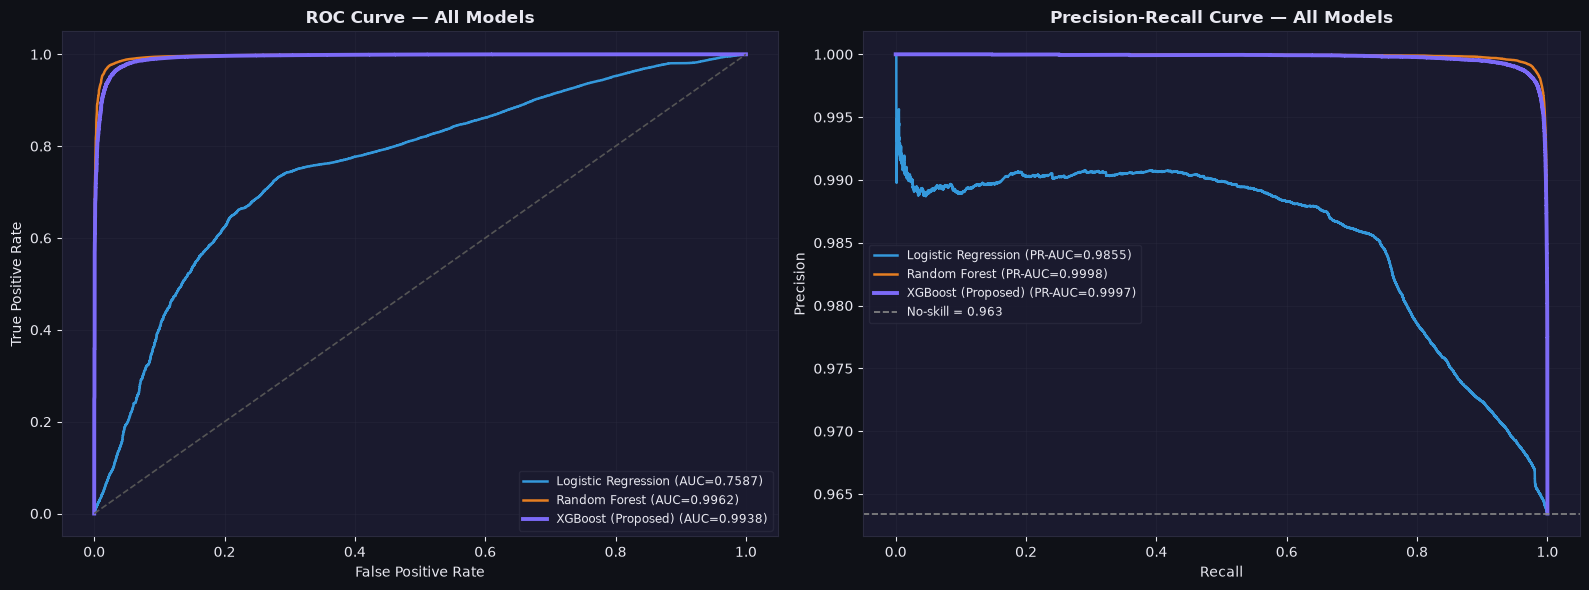

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor=BG)
model_plot_data = [
    ("Majority Classifier", baselines[0]["_probs"], "#555577"),
    ("Logistic Regression",  baselines[1]["_probs"], "#3498db"),
    ("Random Forest",        baselines[2]["_probs"], "#e67e22"),
    ("XGBoost (Proposed)",   test_probs,             TRAIN_C),
]

# ROC
ax = axes[0]
for name, probs, color in model_plot_data:
    if len(np.unique(probs)) < 2:
        continue
    fpr_, tpr_, _ = roc_curve(y_test, probs)
    auc_          = roc_auc_score(y_test, probs)
    lw            = 2.8 if "XGBoost" in name else 1.8
    ax.plot(fpr_, tpr_, color=color, linewidth=lw, label=f"{name} (AUC={auc_:.4f})")
ax.plot([0,1],[0,1],"--",color="#555",linewidth=1.2)
ax.set_title("ROC Curve — All Models", fontweight="bold")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(fontsize=8.5)
ax.grid(True, alpha=0.6)

# PR
ax = axes[1]
for name, probs, color in model_plot_data:
    if len(np.unique(probs)) < 2:
        continue
    prec_, rec_, _ = precision_recall_curve(y_test, probs)
    pr_            = average_precision_score(y_test, probs)
    lw             = 2.8 if "XGBoost" in name else 1.8
    ax.plot(rec_, prec_, color=color, linewidth=lw,
            label=f"{name} (PR-AUC={pr_:.4f})")
baseline_rate = y_test.mean()
ax.axhline(baseline_rate, linestyle="--", color="#888",
           linewidth=1.2, label=f"No-skill = {baseline_rate:.3f}")
ax.set_title("Precision-Recall Curve — All Models", fontweight="bold")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend(fontsize=8.5)
ax.grid(True, alpha=0.6)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/roc_pr_all_models.png", dpi=150,
            bbox_inches="tight", facecolor=BG)
plt.show()


## 15. Confusion Matrix — XGBoost (Proposed)

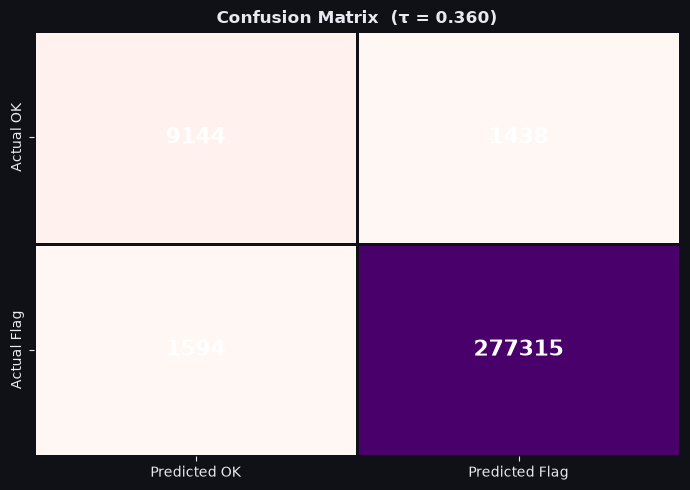

True Positives   : 277315   (bad vendors correctly flagged)
False Negatives  : 1594   (bad vendors missed — minimized by F2 objective)
False Positives  : 1438   (good vendors incorrectly flagged)
True Negatives   : 9144

Recall    : 0.9943   ← priority metric for this system
Precision : 0.9948


In [18]:
cm             = confusion_matrix(y_test, test_preds)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(7, 5), facecolor=BG)
sns.heatmap(cm, annot=True, fmt="d", cmap="RdPu", ax=ax,
            xticklabels=["Predicted OK", "Predicted Flag"],
            yticklabels=["Actual OK",    "Actual Flag"],
            cbar=False,
            annot_kws={"size": 16, "weight": "bold", "color": "white"},
            linewidths=2, linecolor=BG)
ax.set_title(f"Confusion Matrix  (τ = {OPT_THRESH:.3f})", fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/confusion_matrix.png", dpi=150,
            bbox_inches="tight", facecolor=BG)
plt.show()

recall_   = tp / (tp + fn)
precision_= tp / (tp + fp)
print(f"True Positives   : {tp}   (bad vendors correctly flagged)")
print(f"False Negatives  : {fn}   (bad vendors missed — minimized by F2 objective)")
print(f"False Positives  : {fp}   (good vendors incorrectly flagged)")
print(f"True Negatives   : {tn}")
print(f"\nRecall    : {recall_:.4f}   ← priority metric for this system")
print(f"Precision : {precision_:.4f}")


## 16. SHAP Feature Importance

SHAP (SHapley Additive exPlanations) quantifies each feature's marginal contribution
to individual predictions. `TreeExplainer` is exact and efficient for XGBoost.

- **Beeswarm plot** — direction and magnitude of each feature's impact per sample
- **Mean |SHAP| bar** — global feature ranking by average absolute impact


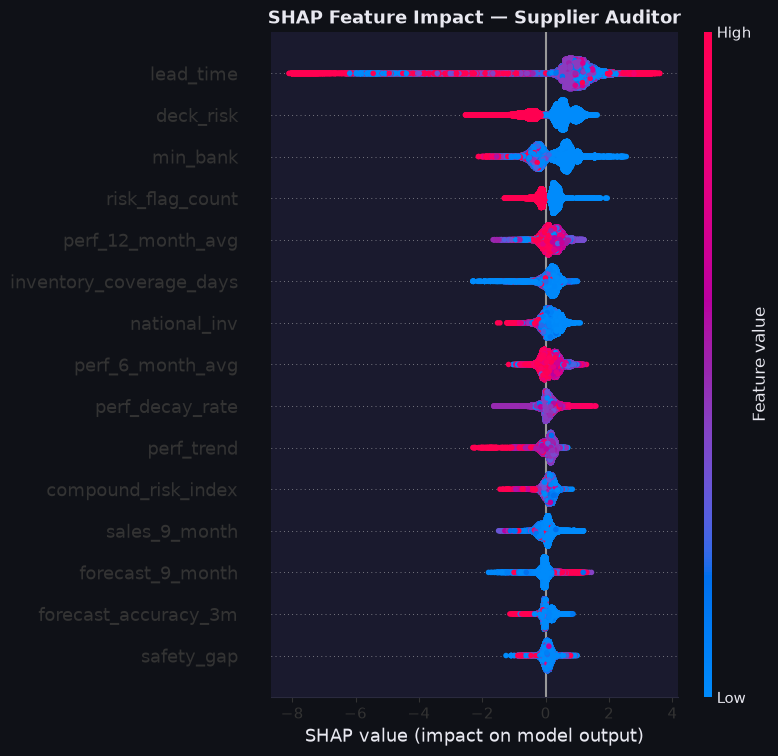

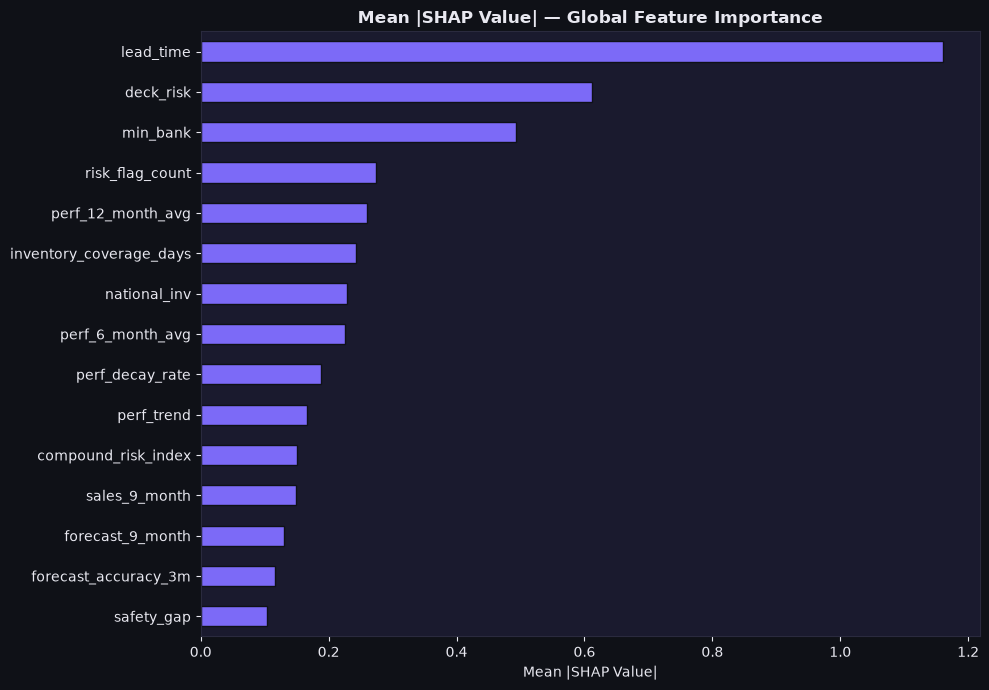

Top 5 features by mean |SHAP|:
  lead_time                      1.16044
  deck_risk                      0.61199
  min_bank                       0.49357
  risk_flag_count                0.27422
  perf_12_month_avg              0.25940


In [19]:
X_test_proc_df = pd.DataFrame(X_test_proc, columns=FEATURE_COLS)
explainer      = shap.TreeExplainer(model)
shap_values    = explainer.shap_values(X_test_proc_df)


fig1, _ = plt.subplots(figsize=(12, 8), facecolor=BG)
shap.summary_plot(shap_values, X_test_proc_df, show=False,
                  plot_type="dot", max_display=15)
plt.title("SHAP Feature Impact — Supplier Auditor",
          color=WHITE, fontsize=13, fontweight="bold")
fig1.patch.set_facecolor(BG)
plt.savefig(f"{OUTPUT_DIR}/shap_beeswarm.png", dpi=150,
            bbox_inches="tight", facecolor=BG)
plt.show()


mean_shap = pd.Series(np.abs(shap_values).mean(axis=0),
                      index=FEATURE_COLS).sort_values(ascending=True)
fig2, ax = plt.subplots(figsize=(10, 7), facecolor=BG)
mean_shap.tail(15).plot(kind="barh", ax=ax, color=TRAIN_C, edgecolor=BG)
ax.set_title("Mean |SHAP Value| — Global Feature Importance", fontweight="bold")
ax.set_xlabel("Mean |SHAP Value|")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/shap_bar.png", dpi=150,
            bbox_inches="tight", facecolor=BG)
plt.show()

print("Top 5 features by mean |SHAP|:")
for feat, val in mean_shap.tail(5).sort_values(ascending=False).items():
    print(f"  {feat:<30} {val:.5f}")


## 17. Supplier Grade Engine

| Grade | Risk Probability | Action |
|---|---|---|
| **A** | [0.00, 0.20) | Approved — no action |
| **B** | [0.20, 0.45) | Watch — schedule contract review |
| **C** | [0.45, 0.70) | At Risk — escalate to procurement |
| **D** | [0.70, 1.00] | Critical — `stop_auto_buy` flag triggered |


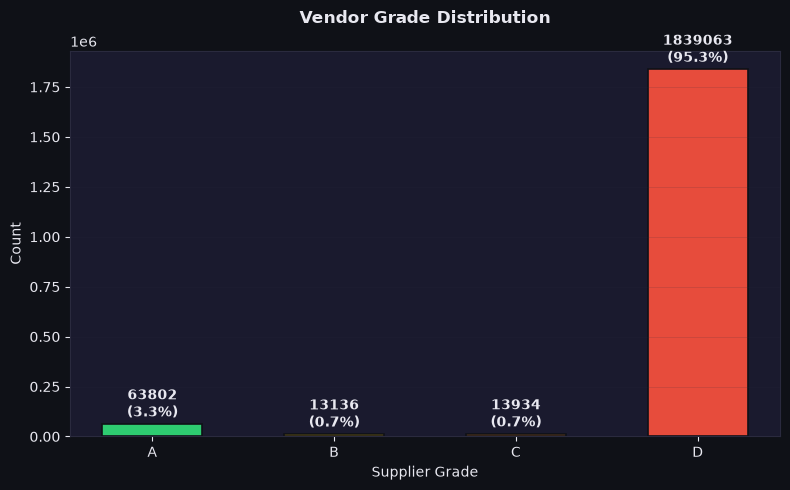

Audit Summary:
  Grade A: 63802 (3.3%)
  Grade B: 13136 (0.7%)
  Grade C: 13934 (0.7%)
  Grade D: 1839063 (95.3%)

Stop Auto-Buy Triggered : 1857126 (96.2%)
  Active threshold used  : τ = 0.3602  ← from Section 8 (not overwritten)

Top 10 highest-risk suppliers:
        sku  risk_probability supplier_grade trigger_reason
SUP-1864010               1.0              D          MODEL
 SUP-621648               1.0              D          MODEL
 SUP-669975               1.0              D          MODEL
SUP-1068267               1.0              D          MODEL
SUP-1896662               1.0              D          MODEL
 SUP-301076               1.0              D          MODEL
SUP-1142056               1.0              D     MODEL+RULE
 SUP-290938               1.0              D          MODEL
SUP-1544114               1.0              D          MODEL
SUP-1863626               1.0              D          MODEL


In [20]:
GRADE_THRESHOLDS = {
    "A": (0.00, 0.20),
    "B": (0.20, 0.45),
    "C": (0.45, 0.70),
    "D": (0.70, 1.01),
}
GRADE_COLORS = {
    "A": "#2ecc71", "B": "#f1c40f",
    "C": "#e67e22", "D": "#e74c3c"
}

def assign_grade(p: float) -> str:
    for grade, (lo, hi) in GRADE_THRESHOLDS.items():
        if lo <= p < hi:
            return grade
    return "D"


all_probs = model.predict_proba(
    preprocessor.transform(X)
)[:, 1]


AUDIT_COLS = ["perf_6_month_avg", "perf_12_month_avg",
              "pieces_past_due", "national_inv", "stop_auto_buy"]
AUDIT_COLS = [c for c in AUDIT_COLS if c in df_raw.columns]  

audit = df_raw[AUDIT_COLS].copy()
audit.reset_index(drop=True, inplace=True)


if "sku" not in audit.columns:
    audit.insert(0, "sku", [f"SUP-{i:05d}" for i in range(len(audit))])

audit["risk_probability"] = np.round(all_probs, 4)
audit["supplier_grade"]   = audit["risk_probability"].apply(assign_grade)
audit["delivery_stress"]  = df_eng["delivery_stress"].reset_index(drop=True)


def flag_logic(row):
    model_flag = row["risk_probability"] >= OPT_THRESH
    rule_flag  = (row["supplier_grade"] == "D") and (row["delivery_stress"] > 0.5)
    triggered  = model_flag or rule_flag
    reason     = ("MODEL+RULE" if (model_flag and rule_flag) else
                  "MODEL"      if model_flag else
                  "RULE"       if rule_flag  else "NONE")
    return pd.Series({"stop_auto_buy_triggered": int(triggered),
                      "trigger_reason": reason})


flags = audit.apply(flag_logic, axis=1)
audit = pd.concat([audit, flags], axis=1).sort_values(
    "risk_probability", ascending=False
).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 5), facecolor=BG)
grade_counts = audit["supplier_grade"].value_counts().reindex(
    ["A", "B", "C", "D"], fill_value=0
)
bars = ax.bar(grade_counts.index, grade_counts.values,
              color=[GRADE_COLORS[g] for g in grade_counts.index],
              edgecolor=BG, linewidth=1.2, width=0.55)
for bar, count in zip(bars, grade_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(grade_counts.values)*0.02,
            f"{count}\n({count/len(audit):.1%})",
            ha="center", color=WHITE, fontsize=10, fontweight="bold")
ax.set_title("Vendor Grade Distribution", fontweight="bold", pad=20)
ax.set_xlabel("Supplier Grade")
ax.set_ylabel("Count")
ax.grid(True, alpha=0.2, axis="y")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/grade_distribution.png", dpi=150,
            bbox_inches="tight", facecolor=BG)
plt.show()

flagged = audit["stop_auto_buy_triggered"].sum()
print("Audit Summary:")
for g in ["A","B","C","D"]:
    cnt = grade_counts.get(g, 0)
    print(f"  Grade {g}: {cnt:>5} ({cnt/len(audit):.1%})")
print(f"\nStop Auto-Buy Triggered : {flagged} ({flagged/len(audit):.1%})")
print(f"  Active threshold used  : τ = {OPT_THRESH:.4f}  ← from Section 8 (not overwritten)")
print("\nTop 10 highest-risk suppliers:")
print(audit.head(10)[["sku", "risk_probability", "supplier_grade",
                       "trigger_reason"]].to_string(index=False))

## 18. Export Audit Report & Model

In [21]:

report_path = f"{OUTPUT_DIR}/vendor_audit_report.csv"
audit.to_csv(report_path, index=False)
print(f"Audit report → {report_path}  ({len(audit)} records)")


model_path = "models/supplier_auditor_model.pkl"
with open(model_path, "wb") as f:
    pickle.dump({"model": model, "preprocessor": preprocessor,
                 "threshold": OPT_THRESH, "feature_cols": FEATURE_COLS}, f,
                protocol=pickle.HIGHEST_PROTOCOL)
size = Path(model_path).stat().st_size / 1024
print(f"Model saved  → {model_path}  ({size:.1f} KB)")
print(f"  Includes: model, preprocessor, OPT_THRESH={OPT_THRESH:.4f}, feature_cols")


Audit report → outputs/vendor_audit_report.csv  (1929935 records)
Model saved  → models/supplier_auditor_model.pkl  (13969.6 KB)
  Includes: model, preprocessor, OPT_THRESH=0.3602, feature_cols


## 19. Results Summary — Q1 Journal Table


In [23]:
print("=" * 72)
print("  SUPPLIER AUDITOR — Q1 JOURNAL RESULTS TABLE")
print("=" * 72)

print("\n[A] Test Set Performance — XGBoost (Proposed)")
print(f"  {'Metric':<22} {'Value':>8}   {'95% CI':>20}  Notes")
print("  " + "─"*68)
metric_display = {
    "F2-Score (β=2)": ("F2-Score", f2),
    "MCC"           : ("MCC",      mcc),
    "ROC-AUC"       : ("ROC-AUC",  roc_auc),
    "PR-AUC"        : ("PR-AUC",   pr_auc),
}
for mname, (key, val) in metric_display.items():
    lo, hi = ci_results.get(mname, (0, 0))
    print(f"  {mname:<22} {val:>8.4f}   [{lo:.4f} – {hi:.4f}]")

print(f"  {'Accuracy':<22} {acc:>8.4f}")
print(f"  {'Log-Loss':<22} {logloss:>8.4f}")
print(f"  {'Optimal Threshold τ':<22} {OPT_THRESH:>8.4f}   (macro-F1-optimized on val set)")
print(f"  {'Best Boosting Round':<22} {BEST_ROUND+1:>8}")

print("\n[B] 5-Fold Cross-Validation — XGBoost (Proposed)")
print(f"  {'Metric':<22} {'Mean':>8}   {'Std':>8}")
print("  " + "─"*42)
for metric, vals in cv_metrics.items():
    print(f"  {metric:<22} {np.mean(vals):>8.4f}   {np.std(vals):>8.4f}")

print("\n[C] Baseline Comparison — Test Set")
print(compare_df[["Model","F2-Score","MCC","ROC-AUC","PR-AUC","Accuracy"]].to_string(index=False))

print("\n[D] Feature Engineering Ablation")
print(abl_df[["Configuration","N Features","F2-Score","MCC","ROC-AUC","PR-AUC"]].to_string(index=False))

print("\n[E] Configuration")
print(f"  Imbalance Handling    : Majority-class undersampling (train split only, kept ratio 1:{UNDERSAMPLE_RATIO:.0f})")
print(f"                          + cost-sensitive scale_pos_weight = {SCALE_POS_WEIGHT:.4f}")
print(f"                          (grid-searched, {SCALE_POS_WEIGHT/SCALE_POS_WEIGHT_HEURISTIC:.2f}x the post-undersampling")
print(f"                          heuristic N_neg/N_pos = {SCALE_POS_WEIGHT_HEURISTIC:.4f})")
print(f"  Synthetic Oversampling: None -- undersampling only drops real majority-class rows,")
print(f"                          val/test sets keep the true 96%/4% distribution")
print(f"  Early Stopping        : patience=40 rounds (val logloss criterion)")
print(f"  Threshold Selection   : Macro-F1-optimized on validation set")
print(f"  Explainability        : SHAP TreeExplainer (Lundberg & Lee, 2017)")
print("=" * 72)


  SUPPLIER AUDITOR — Q1 JOURNAL RESULTS TABLE

[A] Test Set Performance — XGBoost (Proposed)
  Metric                    Value                 95% CI  Notes
  ────────────────────────────────────────────────────────────────────
  F2-Score (β=2)           0.9944   [0.9942 – 0.9946]
  MCC                      0.8524   [0.8473 – 0.8574]
  ROC-AUC                  0.9938   [0.9932 – 0.9944]
  PR-AUC                   0.9997   [0.9997 – 0.9998]
  Accuracy                 0.9895
  Log-Loss                 0.0383
  Optimal Threshold τ      0.3602   (macro-F1-optimized on val set)
  Best Boosting Round         700

[B] 5-Fold Cross-Validation — XGBoost (Proposed)
  Metric                     Mean        Std
  ──────────────────────────────────────────
  F2                       0.9943     0.0002
  MCC                      0.8507     0.0024
  ROC-AUC                  0.9942     0.0002
  PR-AUC                   0.9998     0.0000
  Accuracy                 0.9894     0.0002

[C] Baseline Compari